In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
df.shape

(180519, 53)

In [3]:
print(df['Customer Segment'].value_counts())
print()
print(df['Order Status'].value_counts())
print()
print(df['Category Name'].value_counts().head(10))
print()
print(df[['Sales','Order Item Quantity','Order Item Product Price']].describe())

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64

               Sales  Order Item Quantity  Order Item Product Price
count  180519.000000        180519.000000             180519.000000
mean      203.772096             2.127638                141.232550
std       132.273077             1.453451                139.732492
min         9.9

In [5]:
df['Late_delivery_risk'].value_counts(normalize=True)

,proportion
Late_delivery_risk,
1,0.548291
0,0.451709


In [6]:
ship = df.groupby('Shipping Mode').agg(
    orders=('Order Id','count'),
    actual_days=('Days for shipping (real)','mean'),
    promised_days=('Days for shipment (scheduled)','mean'),
    late_rate=('Late_delivery_risk','mean')
)

ship['slip_days'] = ship['actual_days'] - ship['promised_days']
ship['adherence'] = 1 - ship['late_rate']
ship = ship.sort_values('late_rate', ascending=False)
ship

,orders,actual_days,promised_days,late_rate,slip_days,adherence
Shipping Mode,,,,,,
First Class,27814,2.000000,1.0,0.953225,1.000000,0.046775
Second Class,35216,3.990828,2.0,0.766328,1.990828,0.233672
Same Day,9737,0.478279,0.0,0.457430,0.478279,0.542570
Standard Class,107752,3.995907,4.0,0.380717,-0.004093,0.619283


In [7]:
# test whether late delivery depends on shipping mode
# or if the differences could be random
ct = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])
chi2, p, dof, expected = stats.chi2_contingency(ct)

print('chi-square:', round(chi2, 1))
print('p-value:', p)
print('degrees of freedom:', dof)
ct

chi-square: 37716.0
p-value: 0.0
degrees of freedom: 3


Late_delivery_risk,0,1
Shipping Mode,,
First Class,1301,26513
Same Day,5283,4454
Second Class,8229,26987
Standard Class,66729,41023


In [8]:
seg = df.groupby(['Order Region','Shipping Mode']).agg(
    orders=('Order Id','count'),
    late_rate=('Late_delivery_risk','mean'),
    total_sales=('Sales','sum')
).reset_index()

seg = seg[seg['orders'] >= 100]
seg = seg.sort_values('late_rate', ascending=False)
seg.head(15)

,Order Region,Shipping Mode,orders,late_rate,total_sales
20,East Africa,First Class,280,0.989286,55829.011075
64,Southern Africa,First Class,198,0.984848,37871.120797
76,West Africa,First Class,463,0.978402,89661.691800
68,Southern Europe,First Class,1504,0.972074,332145.316078
36,North Africa,First Class,486,0.971193,96183.321984
52,South Asia,First Class,1283,0.966485,260713.514853
72,US Center,First Class,986,0.964503,191715.863692
24,East of USA,First Class,1089,0.964187,211524.194141
32,Eastern Europe,First Class,658,0.960486,131587.932664
40,Northern Europe,First Class,1418,0.959803,308814.845886


In [9]:
cust = df.groupby(['Customer Segment','Shipping Mode']).agg(
    orders=('Order Id','count'),
    late_rate=('Late_delivery_risk','mean'),
    total_sales=('Sales','sum')
).reset_index()

# focus on the broken express modes
express = cust[cust['Shipping Mode'].isin(['First Class','Second Class'])]
express = express.sort_values('total_sales', ascending=False)
express

,Customer Segment,Shipping Mode,orders,late_rate,total_sales
2,Consumer,Second Class,17997,0.761182,3.667601e+06
0,Consumer,First Class,14407,0.951482,2.951222e+06
6,Corporate,Second Class,10950,0.778995,2.219021e+06
4,Corporate,First Class,8282,0.954359,1.693100e+06
10,Home Office,Second Class,6269,0.758973,1.258823e+06
8,Home Office,First Class,5125,0.956293,1.030047e+06


In [10]:
# build a prioritization score for each region+mode lane
# three factors: how bad the late rate is, how much revenue is exposed,
# how far past the promise it runs

score = df.groupby(['Order Region','Shipping Mode']).agg(
    orders=('Order Id','count'),
    late_rate=('Late_delivery_risk','mean'),
    total_sales=('Sales','sum'),
    actual_days=('Days for shipping (real)','mean'),
    promised_days=('Days for shipment (scheduled)','mean')
).reset_index()

score = score[score['orders'] >= 100].copy()
score['slip_days'] = score['actual_days'] - score['promised_days']

# normalise each factor 0 to 1 so they're comparable
score['late_norm'] = score['late_rate'] / score['late_rate'].max()
score['sales_norm'] = score['total_sales'] / score['total_sales'].max()
score['slip_norm'] = score['slip_days'].clip(lower=0) / score['slip_days'].max()

# weighted priority — late rate and slip weighted higher than revenue
score['priority'] = (
    0.4 * score['late_norm'] +
    0.35 * score['slip_norm'] +
    0.25 * score['sales_norm']
)

score = score.sort_values('priority', ascending=False)

# flag top 20% as urgent
cutoff = score['priority'].quantile(0.80)
score['flag'] = np.where(score['priority'] >= cutoff, 'URGENT', 'monitor')

score[['Order Region','Shipping Mode','orders','late_rate',
       'slip_days','total_sales','priority','flag']].head(15)

,Order Region,Shipping Mode,orders,late_rate,slip_days,total_sales,priority,flag
90,Western Europe,Second Class,5438,0.778963,2.056455,1.169801e+06,0.724225,URGENT
18,Central Asia,Second Class,117,0.863248,2.213675,2.294330e+04,0.700689,URGENT
14,Central America,Second Class,5481,0.750046,1.958219,1.086763e+06,0.691030,URGENT
30,Eastern Asia,Second Class,1406,0.793741,2.115220,2.872055e+05,0.676022,URGENT
10,Central Africa,Second Class,297,0.811448,2.127946,5.742399e+04,0.668669,URGENT
58,South of USA,Second Class,829,0.811821,2.038601,1.551202e+05,0.661720,URGENT
6,Caribbean,Second Class,1631,0.782955,2.030656,3.284354e+05,0.661256,URGENT
50,South America,Second Class,2827,0.750619,1.999646,5.610547e+05,0.660007,URGENT
54,South Asia,Second Class,1552,0.771907,2.043170,3.111076e+05,0.657521,URGENT
86,West of USA,Second Class,1632,0.768382,1.990196,3.222436e+05,0.648521,URGENT


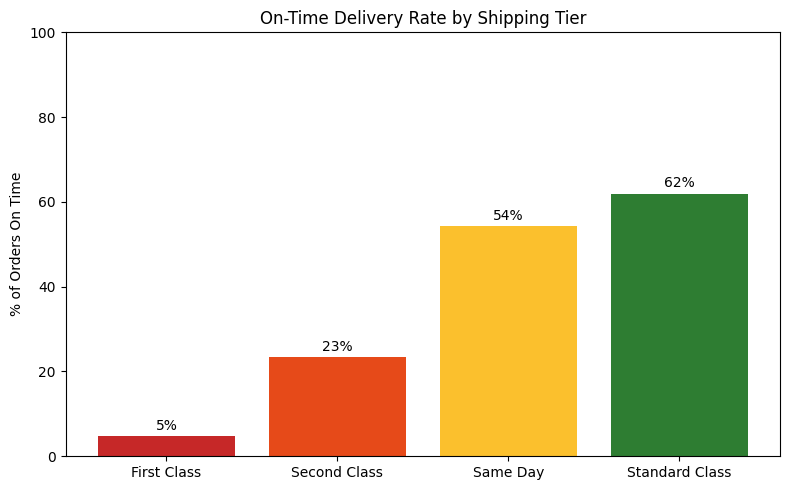

In [11]:
ship_plot = ship.sort_values('adherence')

plt.figure(figsize=(8,5))
bars = plt.bar(ship_plot.index, ship_plot['adherence']*100,
               color=['#c62828','#e64a19','#fbc02d','#2e7d32'])
plt.title('On-Time Delivery Rate by Shipping Tier')
plt.ylabel('% of Orders On Time')
plt.ylim(0,100)
for b, v in zip(bars, ship_plot['adherence']*100):
    plt.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center')
plt.tight_layout()
plt.show()

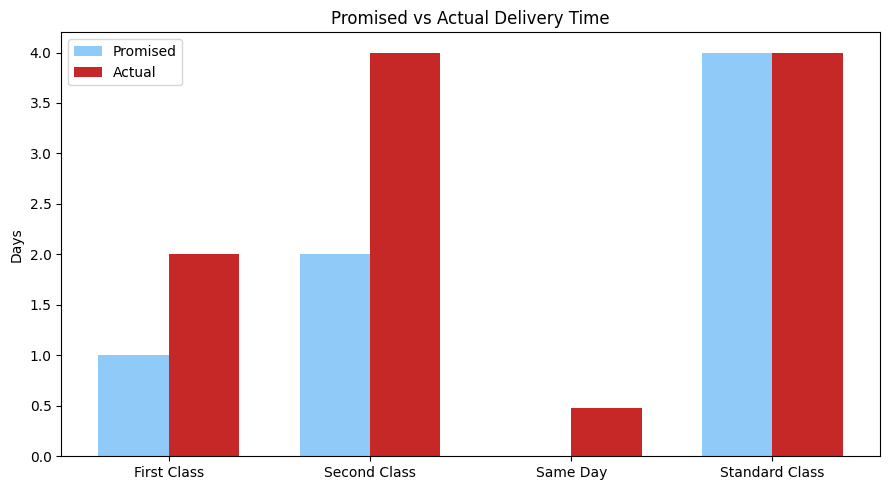

In [12]:
modes = ship.index
x = np.arange(len(modes))
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - w/2, ship['promised_days'], w, label='Promised', color='#90caf9')
plt.bar(x + w/2, ship['actual_days'], w, label='Actual', color='#c62828')
plt.xticks(x, modes)
plt.ylabel('Days')
plt.title('Promised vs Actual Delivery Time')
plt.legend()
plt.tight_layout()
plt.show()

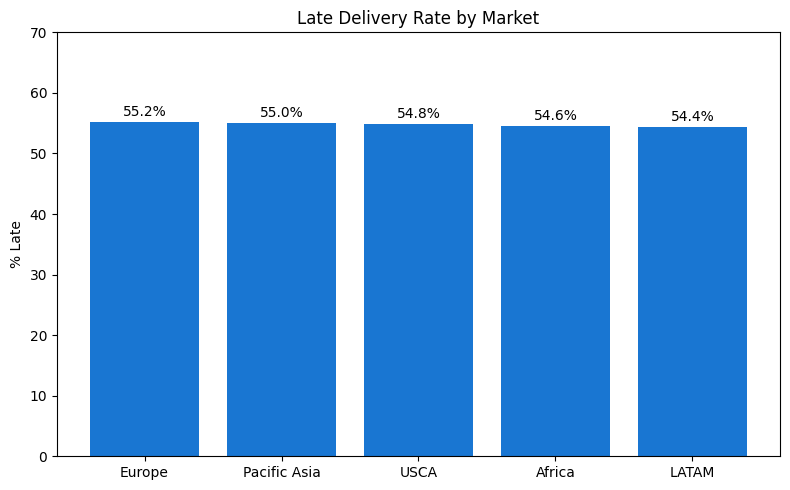

In [13]:
mkt_late = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(mkt_late.index, mkt_late.values*100, color='#1976d2')
plt.title('Late Delivery Rate by Market')
plt.ylabel('% Late')
plt.ylim(0,70)
for i,v in enumerate(mkt_late.values*100):
    plt.text(i, v+1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

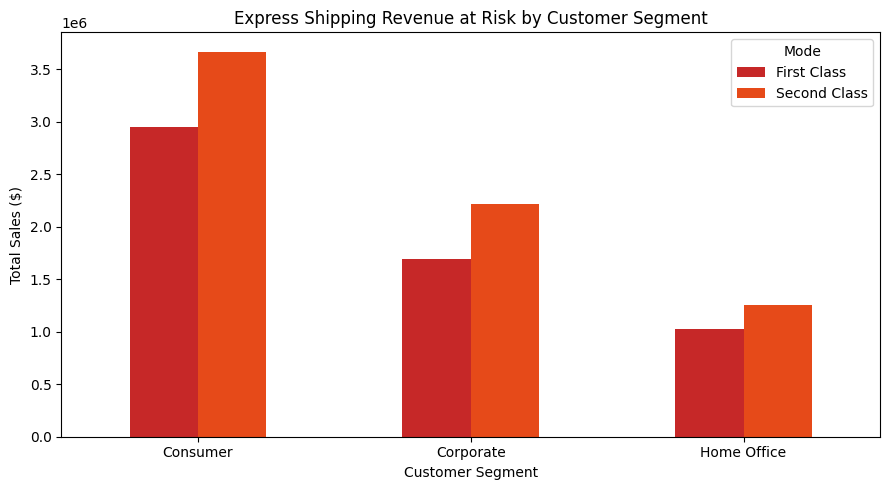

In [14]:
piv = express.pivot(index='Customer Segment', columns='Shipping Mode', values='total_sales')

piv.plot(kind='bar', figsize=(9,5), color=['#c62828','#e64a19'])
plt.title('Express Shipping Revenue at Risk by Customer Segment')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

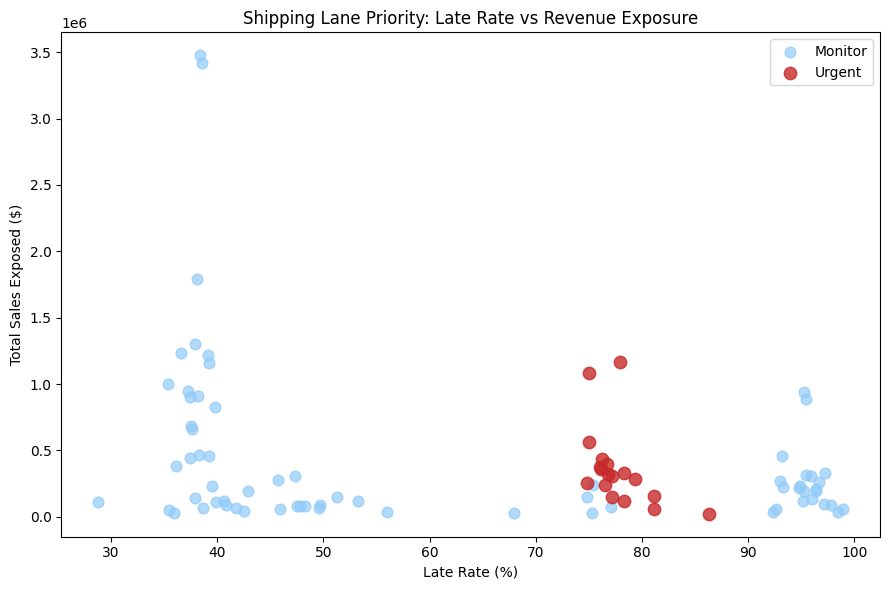

In [15]:
plt.figure(figsize=(9,6))
urgent = score[score['flag']=='URGENT']
monitor = score[score['flag']=='monitor']

plt.scatter(monitor['late_rate']*100, monitor['total_sales'],
            c='#90caf9', s=60, label='Monitor', alpha=0.7)
plt.scatter(urgent['late_rate']*100, urgent['total_sales'],
            c='#c62828', s=80, label='Urgent', alpha=0.8)
plt.xlabel('Late Rate (%)')
plt.ylabel('Total Sales Exposed ($)')
plt.title('Shipping Lane Priority: Late Rate vs Revenue Exposure')
plt.legend()
plt.tight_layout()
plt.show()

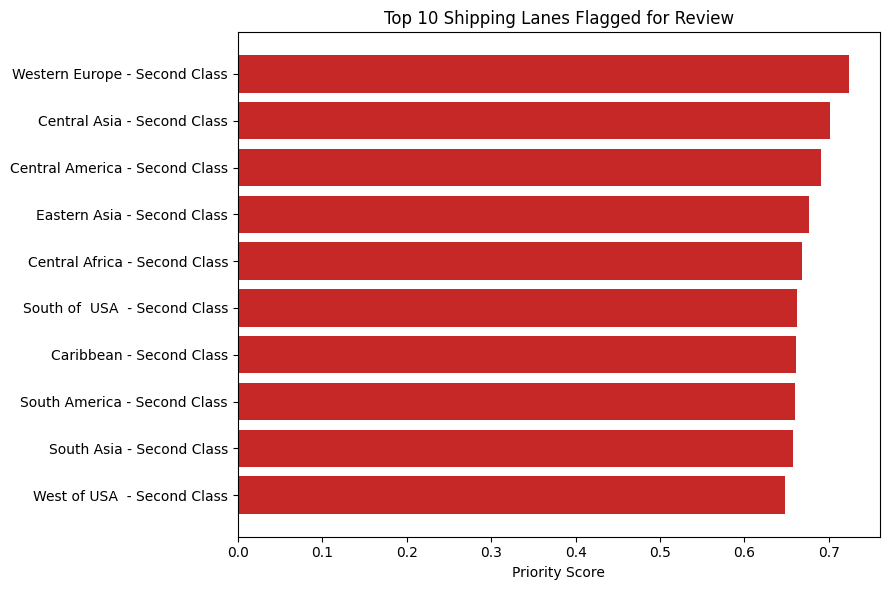

In [16]:
top10 = score.head(10).sort_values('priority')
labels = top10['Order Region'] + ' - ' + top10['Shipping Mode']

plt.figure(figsize=(9,6))
plt.barh(labels, top10['priority'], color='#c62828')
plt.xlabel('Priority Score')
plt.title('Top 10 Shipping Lanes Flagged for Review')
plt.tight_layout()
plt.show()

In [19]:
seg.to_csv('segment_analysis.csv', index=False)
score.to_csv('priority_scoring.csv', index=False)
express.to_csv('segment_exposure.csv', index=False)
ship.to_csv('shipping_mode_performance.csv', index=False)

In [20]:
# save all charts for the readme
ship_plot = ship.sort_values('adherence')
plt.figure(figsize=(8,5))
bars = plt.bar(ship_plot.index, ship_plot['adherence']*100, color=['#c62828','#e64a19','#fbc02d','#2e7d32'])
plt.title('On-Time Delivery Rate by Shipping Tier')
plt.ylabel('% of Orders On Time'); plt.ylim(0,100)
for b,v in zip(bars, ship_plot['adherence']*100):
    plt.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center')
plt.tight_layout(); plt.savefig('01_adherence.png', dpi=150, bbox_inches='tight'); plt.close()

modes = ship.index; x = np.arange(len(modes)); w = 0.35
plt.figure(figsize=(9,5))
plt.bar(x-w/2, ship['promised_days'], w, label='Promised', color='#90caf9')
plt.bar(x+w/2, ship['actual_days'], w, label='Actual', color='#c62828')
plt.xticks(x, modes); plt.ylabel('Days'); plt.title('Promised vs Actual Delivery Time')
plt.legend(); plt.tight_layout(); plt.savefig('02_promised_actual.png', dpi=150, bbox_inches='tight'); plt.close()

mkt_late = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(mkt_late.index, mkt_late.values*100, color='#1976d2')
plt.title('Late Delivery Rate by Market'); plt.ylabel('% Late'); plt.ylim(0,70)
for i,v in enumerate(mkt_late.values*100):
    plt.text(i, v+1, f'{v:.1f}%', ha='center')
plt.tight_layout(); plt.savefig('03_market.png', dpi=150, bbox_inches='tight'); plt.close()

piv = express.pivot(index='Customer Segment', columns='Shipping Mode', values='total_sales')
piv.plot(kind='bar', figsize=(9,5), color=['#c62828','#e64a19'])
plt.title('Express Shipping Revenue at Risk by Customer Segment')
plt.ylabel('Total Sales ($)'); plt.xticks(rotation=0); plt.legend(title='Mode')
plt.tight_layout(); plt.savefig('04_segment_revenue.png', dpi=150, bbox_inches='tight'); plt.close()

plt.figure(figsize=(9,6))
urgent = score[score['flag']=='URGENT']; monitor = score[score['flag']=='monitor']
plt.scatter(monitor['late_rate']*100, monitor['total_sales'], c='#90caf9', s=60, label='Monitor', alpha=0.7)
plt.scatter(urgent['late_rate']*100, urgent['total_sales'], c='#c62828', s=80, label='Urgent', alpha=0.8)
plt.xlabel('Late Rate (%)'); plt.ylabel('Total Sales Exposed ($)')
plt.title('Shipping Lane Priority: Late Rate vs Revenue Exposure'); plt.legend()
plt.tight_layout(); plt.savefig('05_priority_scatter.png', dpi=150, bbox_inches='tight'); plt.close()

top10 = score.head(10).sort_values('priority')
labels = top10['Order Region'] + ' - ' + top10['Shipping Mode']
plt.figure(figsize=(9,6))
plt.barh(labels, top10['priority'], color='#c62828')
plt.xlabel('Priority Score'); plt.title('Top 10 Shipping Lanes Flagged for Review')
plt.tight_layout(); plt.savefig('06_top10.png', dpi=150, bbox_inches='tight'); plt.close()

print('all 6 charts saved')

all 6 charts saved


In [21]:
!zip -r sla_project.zip 01_adherence.png 02_promised_actual.png 03_market.png 04_segment_revenue.png 05_priority_scatter.png 06_top10.png segment_analysis.csv priority_scoring.csv segment_exposure.csv shipping_mode_performance.csv

from google.colab import files
files.download('sla_project.zip')

  adding: 01_adherence.png (deflated 21%)
  adding: 02_promised_actual.png (deflated 23%)
  adding: 03_market.png (deflated 23%)
  adding: 04_segment_revenue.png (deflated 22%)
  adding: 05_priority_scatter.png (deflated 14%)
  adding: 06_top10.png (deflated 23%)
  adding: segment_analysis.csv (deflated 59%)
  adding: priority_scoring.csv (deflated 59%)
  adding: segment_exposure.csv (deflated 41%)
  adding: shipping_mode_performance.csv (deflated 43%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>